# PID Tuning — Interactive Demo

Tune a PID controller against an FOPDT process with live visualization.

**Requirements:** `pip install matplotlib ipywidgets pandas numpy`

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

from pypid import PID, FOPDTSimulator, Mode

## Simulation Engine

In [2]:
def simulate(Kc, Ti, Td, K_proc=2.0, tau_proc=60.0, theta_proc=10.0,
             sp=50.0, pv0=50.0, t_final=600.0, dt=1.0,
             sp_step_time=60.0, sp_step_size=10.0):
    """Run PID + FOPDT simulation. Returns a DataFrame."""
    pid = PID(Kc=Kc, Ti=Ti, Td=Td, setpoint=sp,
              output_limits=(0, 100), sample_time=None, time_base='minutes')
    sim = FOPDTSimulator(K=K_proc, tau=tau_proc, theta=theta_proc, y0=pv0)

    # Initialize at steady state
    ss_output = pv0 / K_proc if K_proc != 0 else 50.0
    pid.mode = Mode.MANUAL
    pid.output = ss_output
    pid(pv0, dt=dt)
    pid.mode = Mode.AUTO

    data = []
    pv = pv0
    n_steps = int(t_final / dt)

    for i in range(n_steps):
        t = i * dt
        if t >= sp_step_time:
            pid.setpoint = sp + sp_step_size

        output = pid(pv, dt=dt)
        pv = sim.update(output, dt=dt)
        p, integ, d = pid.components
        data.append({
            'time': t, 'pv': pv, 'sp': pid.setpoint,
            'output': output, 'P': Kc*p, 'I': Kc*integ, 'D': Kc*d,
            'error': pid.setpoint - pv,
        })

    return pd.DataFrame(data)

## Plotting Function

In [3]:
def plot_response(df, title='PID Step Response'):
    """3-panel plot: PV/SP, Output, PID components."""
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    fig.suptitle(title, fontsize=12)

    # PV and SP
    ax1.plot(df['time'], df['pv'], 'b-', linewidth=1.5, label='PV')
    ax1.plot(df['time'], df['sp'], 'r--', linewidth=1.5, label='SP')
    ax1.set_ylabel('EU')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    ax1.set_title('Process Variable')

    # Output
    ax2.plot(df['time'], df['output'], 'g-', linewidth=1.5)
    ax2.set_ylabel('Output (%)')
    ax2.grid(True, alpha=0.3)
    ax2.set_title('Controller Output')

    # PID Components
    ax3.plot(df['time'], df['P'], label='P', color='orange')
    ax3.plot(df['time'], df['I'], label='I', color='purple')
    ax3.plot(df['time'], df['D'], label='D', color='brown')
    ax3.set_ylabel('Contribution')
    ax3.set_xlabel('Time (seconds)')
    ax3.legend(loc='upper right')
    ax3.grid(True, alpha=0.3)
    ax3.set_title('PID Components')

    plt.tight_layout()
    plt.show()

## 1. Interactive Tuning with Sliders

Adjust Kc, Ti, Td and see the response update live.

In [4]:
@interact(
    Kc=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Kc (gain)'),
    Ti=FloatSlider(value=2.0, min=0.1, max=20.0, step=0.1, description='Ti (min)'),
    Td=FloatSlider(value=0.0, min=0.0, max=1.0, step=0.02, description='Td (min)'),
)
def tune_pid(Kc, Ti, Td):
    df = simulate(Kc=Kc, Ti=Ti, Td=Td)
    plot_response(df, title=f'Kc={Kc:.1f}, Ti={Ti:.1f} min, Td={Td:.2f} min')

interactive(children=(FloatSlider(value=1.0, description='Kc (gain)', max=5.0, min=0.1), FloatSlider(value=2.0…

## 2. Effect of Gain (Kc) — P-Only Control

Shows offset that exists without integral action.

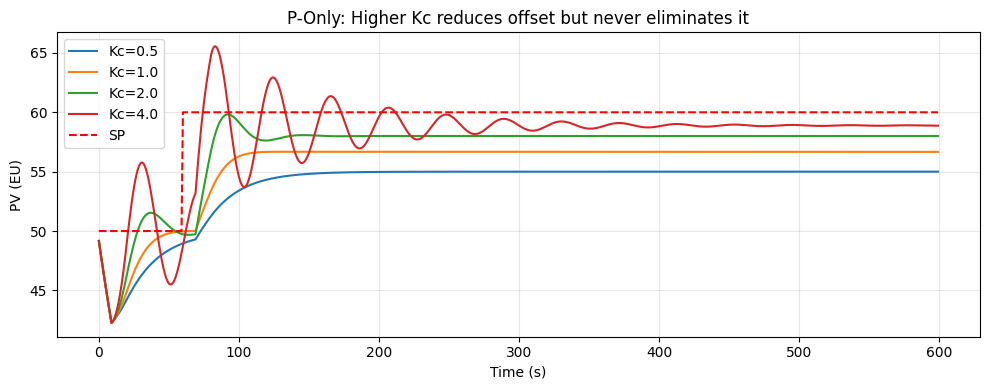

In [5]:
plt.figure(figsize=(10, 4))
for Kc in [0.5, 1.0, 2.0, 4.0]:
    df = simulate(Kc=Kc, Ti=None, Td=None)
    plt.plot(df['time'], df['pv'], label=f'Kc={Kc}')

plt.plot(df['time'], df['sp'], 'r--', label='SP')
plt.title('P-Only: Higher Kc reduces offset but never eliminates it')
plt.xlabel('Time (s)')
plt.ylabel('PV (EU)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Adding Integral Action (PI Control)

Integral eliminates offset. Smaller Ti = faster reset = more aggressive.

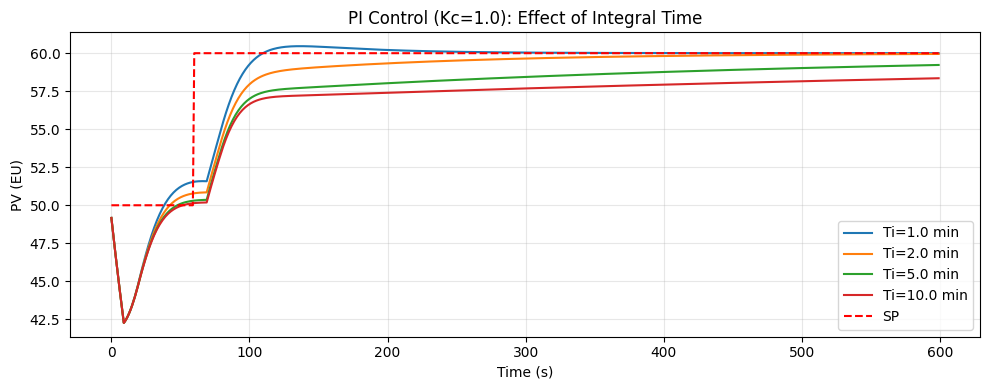

In [6]:
plt.figure(figsize=(10, 4))
for Ti in [1.0, 2.0, 5.0, 10.0]:
    df = simulate(Kc=1.0, Ti=Ti, Td=None)
    plt.plot(df['time'], df['pv'], label=f'Ti={Ti} min')

plt.plot(df['time'], df['sp'], 'r--', label='SP')
plt.title('PI Control (Kc=1.0): Effect of Integral Time')
plt.xlabel('Time (s)')
plt.ylabel('PV (EU)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Adding Derivative Action (PID Control)

Derivative anticipates change, reduces overshoot on slow processes.

In [ ]:
plt.figure(figsize=(10, 4))
for Td in [0.0, 0.3, 0.6, 1.0]:
    label = f'Td={Td} min' if Td > 0 else 'PI only (Td=0)'
    df = simulate(Kc=1.5, Ti=2.0, Td=Td)
    plt.plot(df['time'], df['pv'], label=label)

plt.plot(df['time'], df['sp'], 'r--', label='SP')
plt.title('PID Control (Kc=1.5, Ti=2.0 min): Effect of Derivative Time')
plt.xlabel('Time (s)')
plt.ylabel('PV (EU)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Process Dead Time — What Makes Tuning Hard?

Same tuning, different dead times.

In [ ]:
plt.figure(figsize=(10, 4))
for theta in [2.0, 10.0, 30.0, 60.0]:
    df = simulate(Kc=1.0, Ti=2.0, Td=0.3, theta_proc=theta)
    plt.plot(df['time'], df['pv'], label=f'θ={theta}s')

plt.plot(df['time'], df['sp'], 'r--', label='SP')
plt.title('Same tuning, different dead times — larger θ = harder to control')
plt.xlabel('Time (s)')
plt.ylabel('PV (EU)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Full Interactive: Controller + Process Sliders

In [ ]:
@interact(
    Kc=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Kc'),
    Ti=FloatSlider(value=2.0, min=0.1, max=20.0, step=0.1, description='Ti (min)'),
    Td=FloatSlider(value=0.0, min=0.0, max=1.0, step=0.02, description='Td (min)'),
    K_proc=FloatSlider(value=2.0, min=0.5, max=5.0, step=0.1, description='K (gain)'),
    tau_proc=FloatSlider(value=60.0, min=10.0, max=200.0, step=5.0, description='τ (sec)'),
    theta_proc=FloatSlider(value=10.0, min=0.0, max=60.0, step=1.0, description='θ (sec)'),
)
def full_tuning(Kc, Ti, Td, K_proc, tau_proc, theta_proc):
    df = simulate(Kc=Kc, Ti=Ti, Td=Td,
                  K_proc=K_proc, tau_proc=tau_proc, theta_proc=theta_proc)
    
    # Performance metrics
    sp_region = df[df['time'] >= 60.0]
    overshoot = (sp_region['pv'].max() - sp_region['sp'].iloc[0]) / 10.0 * 100
    iae = np.trapz(np.abs(sp_region['error']), sp_region['time'])
    
    title = f'Kc={Kc:.1f}, Ti={Ti:.1f}min, Td={Td:.1f}min | OS={overshoot:.0f}% | IAE={iae:.0f}'
    plot_response(df, title=title)

## 7. Lambda Tuning Rule of Thumb

| Rule | Kc | Ti | Td |
|------|----|----|----|
| Start conservative | 0.5/K | 2×τ (in min) | 0 |
| Lambda (non-aggressive) | τ/(K×λ) | τ (in min) | 0 |

Where λ = desired closed-loop time constant, typically 3×θ.

In [ ]:
# Process parameters
K, tau, theta = 2.0, 60.0, 10.0

# Lambda tuning: lambda = 3 * theta
lam = 3 * theta
Kc_lambda = tau / (K * lam)
Ti_lambda = tau / 60.0  # convert tau (seconds) to minutes

print(f'Process: K={K}, τ={tau}s, θ={theta}s')
print(f'Lambda tuning (λ={lam}s): Kc={Kc_lambda:.2f}, Ti={Ti_lambda:.2f} min')

df = simulate(Kc=Kc_lambda, Ti=Ti_lambda, Td=None,
              K_proc=K, tau_proc=tau, theta_proc=theta)
plot_response(df, title=f'Lambda Tuning: Kc={Kc_lambda:.2f}, Ti={Ti_lambda:.2f} min')